# Ceteris paribus profiles — module 01

Molnar, *Interpretable Machine Learning*, **chapter 12**.

A ceteris paribus profile is the simplest question you can ask a model:
*hold everything about this patient fixed, move one measurement, and watch
the prediction*. It needs no surrogate, no sampling, no kernel. One feature,
one grid, one curve.

It is also the first place in this course where the model is asked about
patients who do not exist — and this notebook measures how much of the curve
is made of them.

The model, the split, the seed and the patient are **identical to module 03**,
so the four modules can be read as one continuous case.

In [1]:
%pip install -q scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

RANDOM_STATE = 42
BLUE = "#315B86"        # benign
TERRACOTTA = "#C96F3F"  # malignant
DARK = "#252525"
GRAY = "#A8A8A8"

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 140})

## The model, and the patient

Same as module 03, deliberately: a 300-tree RandomForest on the Breast Cancer
Wisconsin data, and test patient #67, who sits close to the decision boundary
at P(benign) = 0.581.

In [3]:
data = load_breast_cancer()
X_all, y_all = data.data, data.target
feature_names = list(data.feature_names)
class_names = list(data.target_names)  # ['malignant', 'benign']
feat_idx = {f: i for i, f in enumerate(feature_names)}

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RANDOM_STATE, stratify=y_all
)
model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, model.predict(X_test))
test_auc = roc_auc_score(y_test, proba_test)

instance_idx = 67
row = X_test[instance_idx]
row_proba = proba_test[instance_idx]

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

print(f"patient #{instance_idx}: P(benign) = {row_proba:.3f}   "
      f"predicted {class_names[int(row_proba >= 0.5)]}, truly {class_names[y_test[instance_idx]]}")
print(f"model: test accuracy {test_acc:.1%}, ROC-AUC {test_auc:.3f}   "
      f"({len(X_train)} train / {len(X_test)} test)")

patient #67: P(benign) = 0.581   predicted benign, truly benign
model: test accuracy 95.1%, ROC-AUC 0.993   (426 train / 143 test)


## The definition, and the one line of code it takes

For feature $j$, a grid $z_1 \dots z_k$, and instance $\mathbf{x}$:

$$\text{CP}_j(z) = \hat{f}\big(z, \mathbf{x}_{-j}\big)$$

Everything except $x_j$ stays at this patient's values. That is the whole
method. The interesting part is not the computation — it is what those
manufactured rows are.

In [4]:
FIG_DIR = "figures_generated"  # regenerated on each run; committed copies live in ../figures
os.makedirs(FIG_DIR, exist_ok=True)


def cp_profile(base_row, j, grid):
    """f along a grid of feature j, everything else frozen at base_row."""
    probe = np.tile(base_row, (len(grid), 1))
    probe[:, j] = grid
    return model.predict_proba(probe)[:, 1]


def feature_grid(j, span=2.5, n=200):
    """An equidistant grid, ±span sigma around the patient, clipped to the
    range the feature actually takes in the full dataset."""
    lo = max(X_all[:, j].min(), row[j] - span * train_std[j])
    hi = min(X_all[:, j].max(), row[j] + span * train_std[j])
    return np.linspace(lo, hi, n)


def save_figure(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=200, bbox_inches="tight")


def new_figure(title, figsize=(8.5, 5.2)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=12)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    return fig, ax

## Step 1 — one profile

`worst perimeter` is the feature LIME ranks first for this patient in module
03, so it is the natural one to sweep.

**What to look for.** The curve is a *staircase*, not a slope. A forest is
piecewise constant: it can only change its mind when a split is crossed. The
steps are where the model's answer actually lives; between them, moving the
measurement does nothing at all.

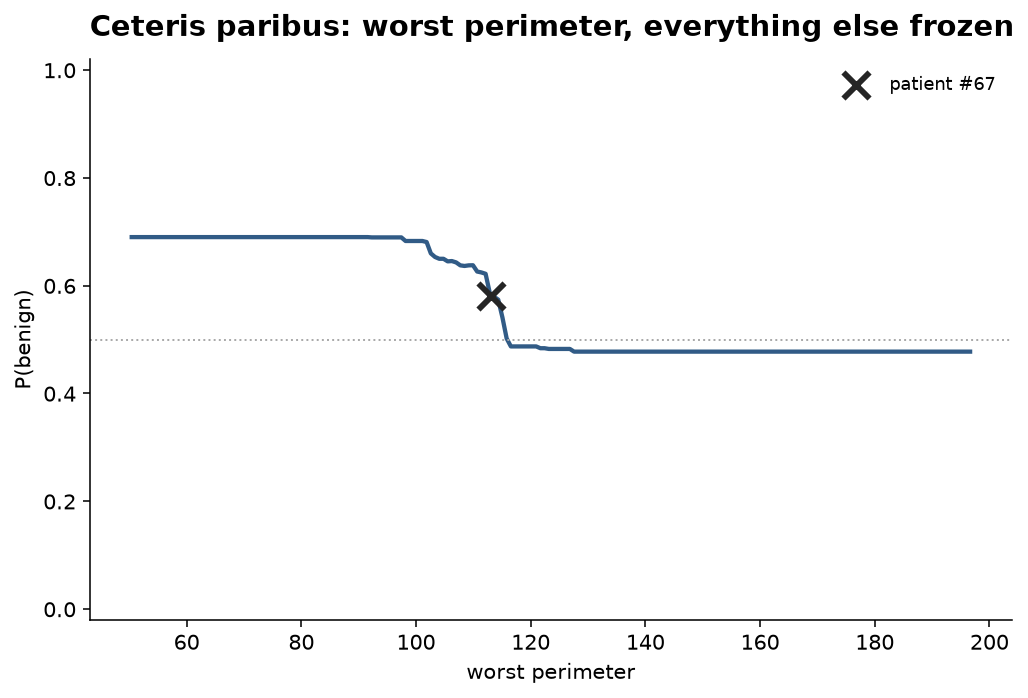

the curve spans P = 0.478 to 0.690  (a swing of 0.212)
steps larger than 0.01: 6 of 199 grid intervals
the largest single step is 0.039, at worst perimeter = 115.1


In [5]:
J = feat_idx["worst perimeter"]
grid = feature_grid(J)
prof = cp_profile(row, J, grid)

fig, ax = new_figure("Ceteris paribus: worst perimeter, everything else frozen")
ax.plot(grid, prof, color=BLUE, linewidth=2.2)
ax.axhline(0.5, color=GRAY, linewidth=1.0, linestyle=":")
ax.scatter([row[J]], [row_proba], s=180, marker="x", color=DARK, linewidths=3.0,
           zorder=10, label=f"patient #{instance_idx}")
ax.set_xlabel("worst perimeter")
ax.set_ylabel("P(benign)")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper right", fontsize=9.5, framealpha=0.93, edgecolor="none")
save_figure(fig, "cp_step_1_profile")
plt.show()

steps = np.abs(np.diff(prof))
big = steps > 0.01
print(f"the curve spans P = {prof.min():.3f} to {prof.max():.3f}  "
      f"(a swing of {prof.max() - prof.min():.3f})")
print(f"steps larger than 0.01: {big.sum()} of {len(steps)} grid intervals")
print(f"the largest single step is {steps.max():.3f}, at "
      f"worst perimeter = {grid[np.argmax(steps)]:.1f}")

## Step 2 — how many of those rows could exist?

Module 03 measured the constraint we need: across all 569 real patients, the
ratio `worst perimeter / worst radius` stays between **6.22 and 7.67**. It has
to — the two measure the same object, and a closed shape has a perimeter
roughly $2\pi$ times its radius.

The sweep above moves the perimeter while **freezing the radius**. So it
drives that ratio wherever it likes.

**What to look for.** The shaded band is the part of the x-axis where the
resulting patient is geometrically possible. Everything outside it is a
tumour that cannot be built.

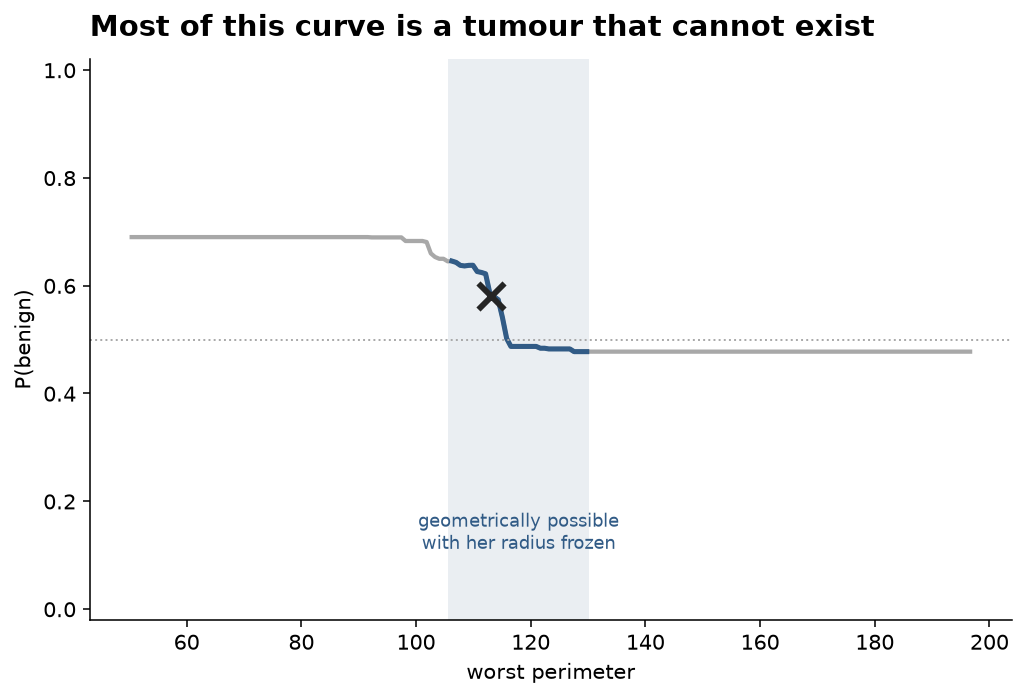

real perimeter/radius ratio, all 569 patients: 6.22 to 7.67
her worst radius is frozen at 16.97, so the perimeter can only run 105.6 to 130.2
of the 200 grid points plotted, 167 (84%) are impossible patients

and the decisive question: the largest step sits at 115.1, INSIDE the possible range
  so the headline of this plot survives — what the model does where this
  patient could actually be is the same thing the full curve showed.
  That is a result about this feature, not a guarantee. Check it every time.


In [6]:
R = feat_idx["worst radius"]
ratio_real = X_all[:, feat_idx["worst perimeter"]] / X_all[:, R]
lo_ratio, hi_ratio = ratio_real.min(), ratio_real.max()

# with the radius frozen at hers, the perimeter can only live in this interval
poss_lo, poss_hi = lo_ratio * row[R], hi_ratio * row[R]
possible = (grid >= poss_lo) & (grid <= poss_hi)

fig, ax = new_figure("Most of this curve is a tumour that cannot exist")
ax.axvspan(poss_lo, poss_hi, color=BLUE, alpha=0.10, lw=0)
ax.plot(grid, prof, color=GRAY, linewidth=2.2)
ax.plot(grid[possible], prof[possible], color=BLUE, linewidth=2.6)
ax.axhline(0.5, color=GRAY, linewidth=1.0, linestyle=":")
ax.scatter([row[J]], [row_proba], s=180, marker="x", color=DARK, linewidths=3.0, zorder=10)
ax.annotate("geometrically possible\nwith her radius frozen",
            xy=((poss_lo + poss_hi) / 2, 0.10), ha="center", va="bottom",
            fontsize=9.5, color=BLUE)
ax.set_xlabel("worst perimeter")
ax.set_ylabel("P(benign)")
ax.set_ylim(-0.02, 1.02)
save_figure(fig, "cp_step_2_impossible")
plt.show()

print(f"real perimeter/radius ratio, all 569 patients: {lo_ratio:.2f} to {hi_ratio:.2f}")
print(f"her worst radius is frozen at {row[R]:.2f}, so the perimeter can only run "
      f"{poss_lo:.1f} to {poss_hi:.1f}")
print(f"of the {len(grid)} grid points plotted, {(~possible).sum()} "
      f"({(~possible).mean():.0%}) are impossible patients")

step_at = grid[np.argmax(steps)]
inside = poss_lo <= step_at <= poss_hi
print(f"\nand the decisive question: the largest step sits at {step_at:.1f}, "
      f"{'INSIDE' if inside else 'OUTSIDE'} the possible range")
print("  so the headline of this plot survives — what the model does where this")
print("  patient could actually be is the same thing the full curve showed.")
print("  That is a result about this feature, not a guarantee. Check it every time.")

## Step 3 — the general criterion, and why it fails

The perimeter/radius test works because we happen to know a physical law
linking two columns. Most datasets give no such gift, so the obvious general
substitute is distance: for each point on the sweep, how far is the
manufactured patient from the nearest *real* one? Anything further away than
real patients get from each other is somewhere the data never goes.

**It does not work, and the reason is worth more than the test.** Watch the
numbers below before reading on.

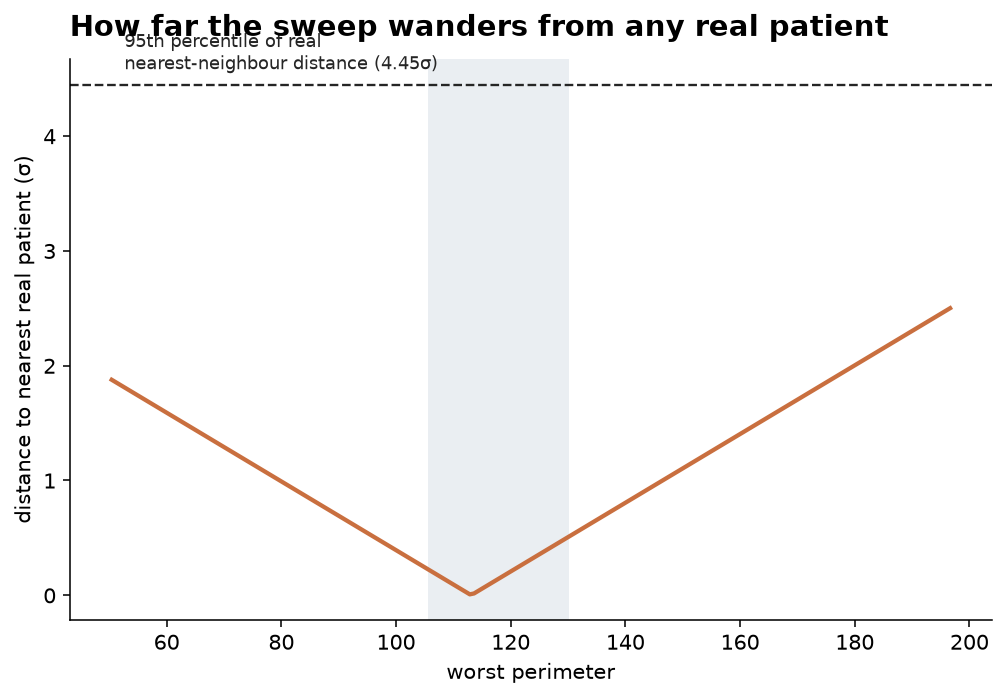

real patients sit within 4.45σ of a neighbour (95th percentile)
the sweep exceeds that for 0% of the grid
at its worst the manufactured patient is 2.50σ from anything real

Two criteria, opposite verdicts. Geometry rejects 84% of the curve; distance-to-data rejects 0%.

The distance test cannot see the problem, and it is not a bad implementation.
Moving ONE of 30 features by a few sigma moves the row by a few sigma. Two
real patients differ on all 30 at once, so they sit about sqrt(2*30) = 7.7
sigma apart. A one-feature sweep is far too small a step to look unusual by
that measure — no matter how absurd the row it produces.

That is the uncomfortable part: a ceteris paribus row is geometrically
impossible and statistically unremarkable at the same time. An
out-of-distribution check based on distance will wave it through.


In [7]:
Z_all = (X_all - train_mean) / train_std


def nn_distance(rows_scaled):
    """Distance from each row to the closest real patient, in sigma units."""
    d = np.linalg.norm(rows_scaled[:, None, :] - Z_all[None, :, :], axis=2)
    return d.min(axis=1)


real_nn = np.sort(np.partition(
    np.linalg.norm(Z_all[:, None, :] - Z_all[None, :, :], axis=2), 1, axis=1)[:, 1])
yardstick = np.percentile(real_nn, 95)

probe = np.tile(row, (len(grid), 1))
probe[:, J] = grid
sweep_nn = nn_distance((probe - train_mean) / train_std)

fig, ax = new_figure("How far the sweep wanders from any real patient")
ax.plot(grid, sweep_nn, color=TERRACOTTA, linewidth=2.2)
ax.axhline(yardstick, color=DARK, linewidth=1.2, linestyle="--")
ax.annotate(f"95th percentile of real\nnearest-neighbour distance ({yardstick:.2f}σ)",
            xy=(grid[3], yardstick), xytext=(0, 8), textcoords="offset points",
            fontsize=9.5, color=DARK)
ax.axvspan(poss_lo, poss_hi, color=BLUE, alpha=0.10, lw=0)
ax.set_xlabel("worst perimeter")
ax.set_ylabel("distance to nearest real patient (σ)")
save_figure(fig, "cp_step_3_distance")
plt.show()

print(f"real patients sit within {yardstick:.2f}σ of a neighbour (95th percentile)")
print(f"the sweep exceeds that for {(sweep_nn > yardstick).mean():.0%} of the grid")
print(f"at its worst the manufactured patient is {sweep_nn.max():.2f}σ from anything real")
print(f"\nTwo criteria, opposite verdicts. Geometry rejects "
      f"{(~possible).mean():.0%} of the curve; distance-to-data rejects "
      f"{(sweep_nn > yardstick).mean():.0%}.")
print("\nThe distance test cannot see the problem, and it is not a bad implementation.")
print("Moving ONE of 30 features by a few sigma moves the row by a few sigma. Two")
print("real patients differ on all 30 at once, so they sit about sqrt(2*30) = 7.7")
print("sigma apart. A one-feature sweep is far too small a step to look unusual by")
print("that measure — no matter how absurd the row it produces.")
print("\nThat is the uncomfortable part: a ceteris paribus row is geometrically")
print("impossible and statistically unremarkable at the same time. An")
print("out-of-distribution check based on distance will wave it through.")

## Step 4 — the remedy the book proposes, tested

Molnar's advice for correlated features is to restrict the curve: *"you might
want to restrict the range of the curve to more realistic intervals."*

So restrict it. Keep only the part of the sweep that is geometrically
possible, and ask what is left of the story.

**What to look for.** Whether the restricted curve still says what the full
one said. If the interesting behaviour was in the discarded part, the remedy
does not rescue the plot — it deletes it. Here it is cheap: most of the swing
is inside the realistic interval and the crossing of P = 0.5 survives. That is
a fact about this feature, and the reason to run the check rather than assume
either outcome.

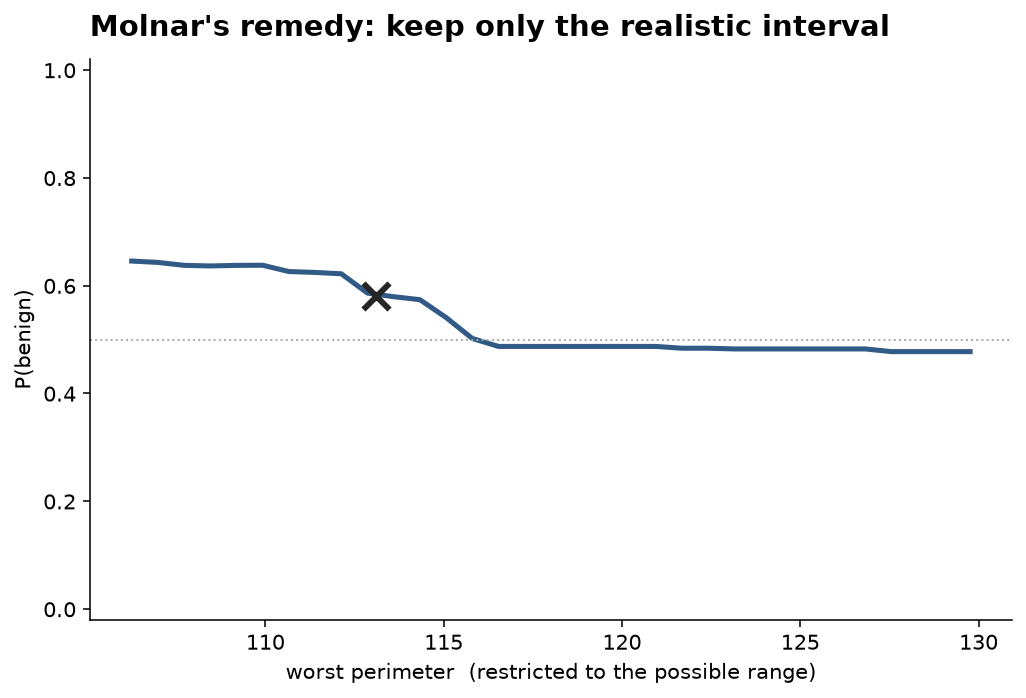

swing in P:      full sweep 0.212   restricted 0.168   (79% survives)
crosses P=0.5:   full sweep True   restricted True


In [8]:
fig, ax = new_figure("Molnar's remedy: keep only the realistic interval")
ax.plot(grid[possible], prof[possible], color=BLUE, linewidth=2.6)
ax.axhline(0.5, color=GRAY, linewidth=1.0, linestyle=":")
ax.scatter([row[J]], [row_proba], s=180, marker="x", color=DARK, linewidths=3.0, zorder=10)
ax.set_xlabel("worst perimeter  (restricted to the possible range)")
ax.set_ylabel("P(benign)")
ax.set_ylim(-0.02, 1.02)
save_figure(fig, "cp_step_4_restricted")
plt.show()

swing_full = prof.max() - prof.min()
swing_rest = prof[possible].max() - prof[possible].min()
crosses_full = np.any(prof >= 0.5) and np.any(prof < 0.5)
crosses_rest = np.any(prof[possible] >= 0.5) and np.any(prof[possible] < 0.5)
print(f"swing in P:      full sweep {swing_full:.3f}   restricted {swing_rest:.3f}   "
      f"({swing_rest / swing_full:.0%} survives)")
print(f"crosses P=0.5:   full sweep {crosses_full}   restricted {crosses_rest}")

## The same measurement, across her strongest features

One feature could be a special case. Here are the six the forest leans on
most, each swept the same way, each with its possible range shaded.

**What to look for.** The impossible fraction is not a quirk of perimeter. It
is what the method does.

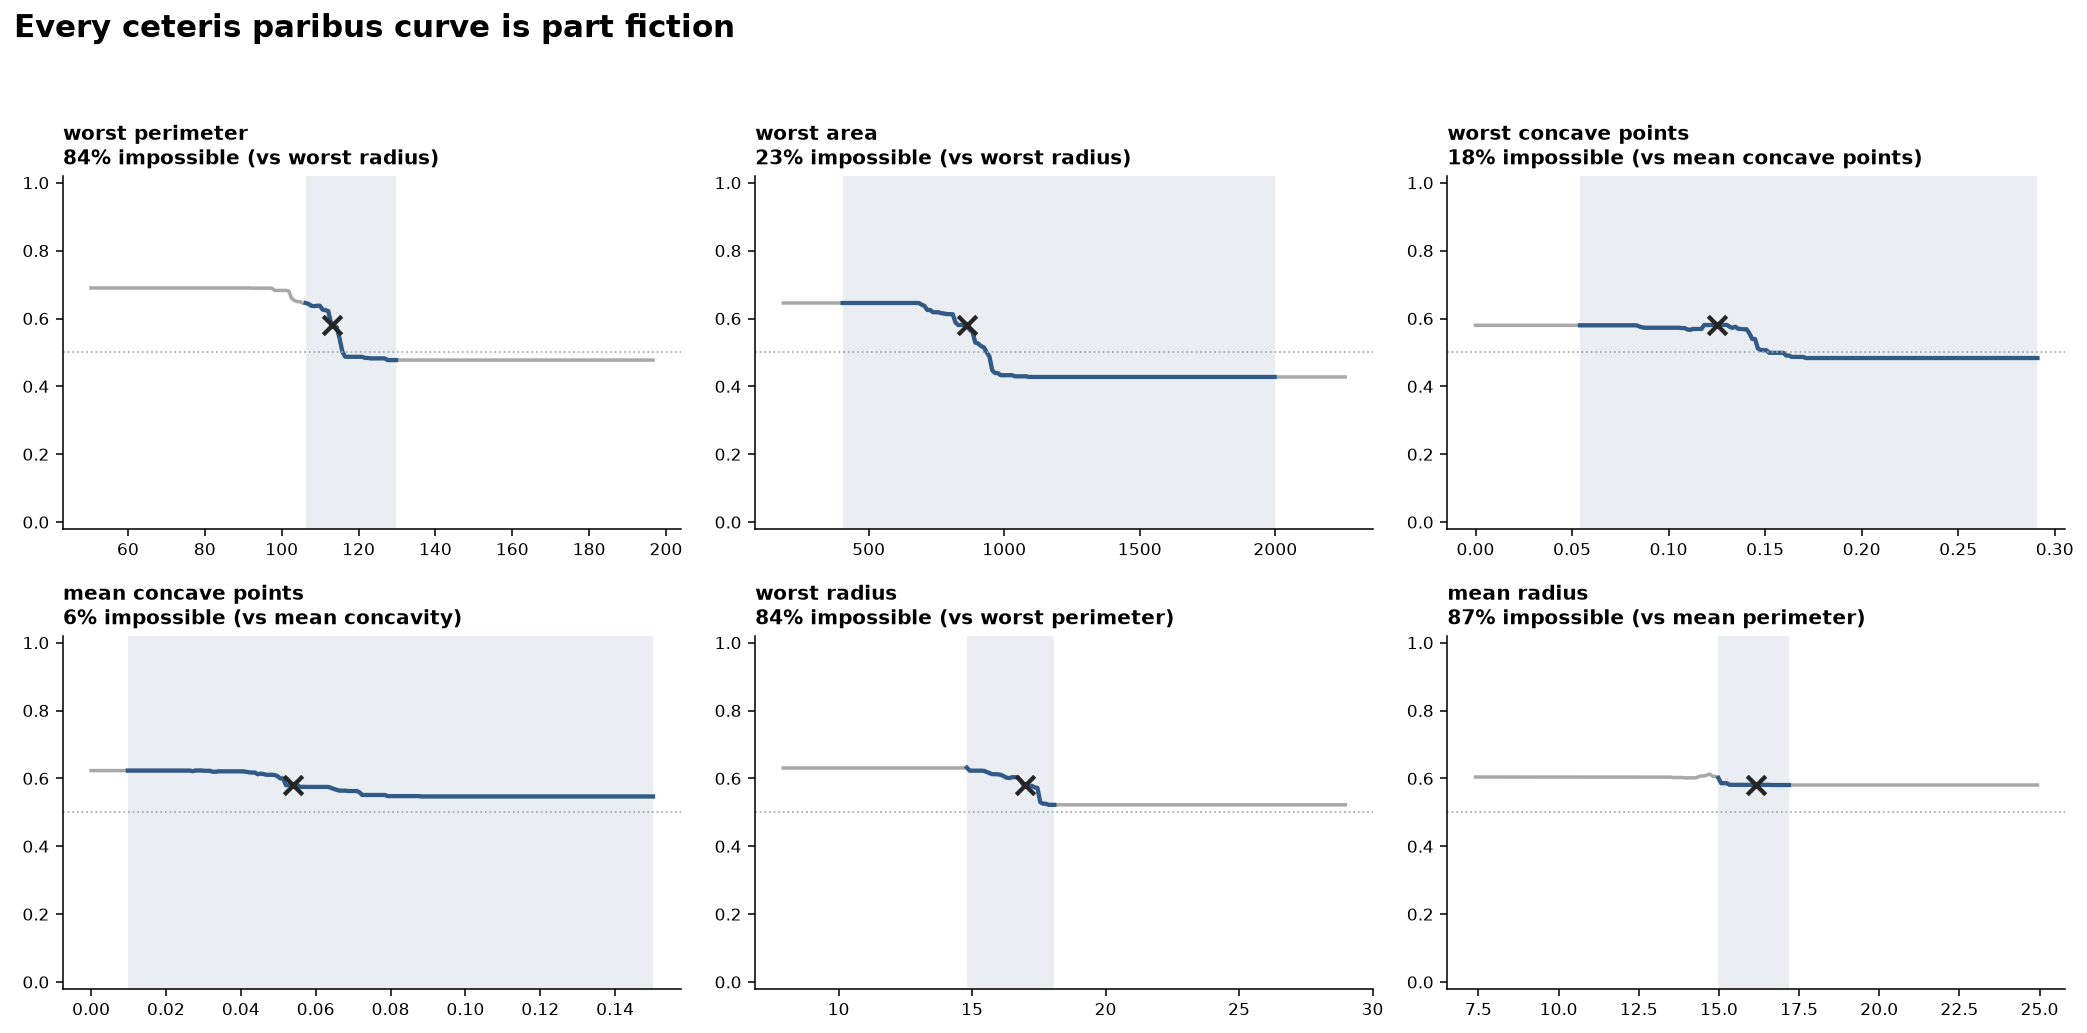

feature                     impossible  swing in P
worst perimeter                   84%       0.212
worst area                        23%       0.218
worst concave points              18%       0.098
mean concave points                6%       0.077
worst radius                      84%       0.110
mean radius                       87%       0.032

median impossible fraction over the six: 53%


In [9]:
top6 = np.argsort(-model.feature_importances_)[:6]
partner = {}
for j in top6:
    # the training-set feature most correlated with j is the one being violated
    c = np.abs([np.corrcoef(X_train[:, j], X_train[:, k])[0, 1] if k != j else 0
                for k in range(len(feature_names))])
    partner[j] = int(np.argmax(c))

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
summary = []
for ax, j in zip(axes.ravel(), top6):
    g = feature_grid(j)
    p = cp_profile(row, j, g)
    k = partner[j]
    r_real = X_all[:, j] / np.where(X_all[:, k] == 0, np.nan, X_all[:, k])
    lo_r, hi_r = np.nanmin(r_real), np.nanmax(r_real)
    ok = (g >= lo_r * row[k]) & (g <= hi_r * row[k]) if row[k] != 0 else np.ones_like(g, bool)
    ax.axvspan(g[ok].min(), g[ok].max(), color=BLUE, alpha=0.10, lw=0) if ok.any() else None
    ax.plot(g, p, color=GRAY, linewidth=1.8)
    ax.plot(g[ok], p[ok], color=BLUE, linewidth=2.2)
    ax.axhline(0.5, color=GRAY, linewidth=0.9, linestyle=":")
    ax.scatter([row[j]], [row_proba], s=90, marker="x", color=DARK, linewidths=2.2, zorder=10)
    ax.set_title(f"{feature_names[j]}\n{(~ok).mean():.0%} impossible "
                 f"(vs {feature_names[k]})", loc="left", fontsize=10.5, fontweight="bold")
    ax.set_ylim(-0.02, 1.02)
    ax.tick_params(labelsize=8.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    summary.append((feature_names[j], (~ok).mean(), p.max() - p.min()))
fig.suptitle("Every ceteris paribus curve is part fiction", x=0.007, ha="left",
             fontsize=16, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_figure(fig, "cp_top_features")
plt.show()

print(f"{'feature':<26} {'impossible':>11} {'swing in P':>11}")
for name, frac, swing in summary:
    print(f"{name:<26} {frac:>10.0%} {swing:>11.3f}")
print(f"\nmedian impossible fraction over the six: "
      f"{np.median([f for _, f, _ in summary]):.0%}")

## What to carry to the next module

A ceteris paribus profile is honest about one thing and silent about another.

It is honest about **the model**: the staircase is exactly what the forest
does, computed and not sketched. Nothing is approximated, and there is no
surrogate standing between you and $\hat{f}$.

It is silent about **whether the question is meaningful**. Freezing 29
measurements while one moves builds patients that could not be biopsied — 84%
of the plotted curve on her strongest feature, and a median of 53% across the
six features the forest leans on most.

And the check most people would reach for does not catch it. A distance-based
out-of-distribution test clears 100% of that sweep, because a one-feature move
is a small step in 30 dimensions even when it is a physically absurd one.
Only a constraint that knows something about the *domain* — here, that a
perimeter and a radius describe the same object — can see it.

That is not a defect of the plot. It is the price of the *ceteris paribus*
clause itself, and every method in this course pays some version of it — LIME
pays it in 30 dimensions at once, where module 03 measures 76% of its probe
rows carrying an impossible measurement.

Module 02 stacks these curves, one per patient, and asks what the average of
them hides.

In [10]:
print("Technical companion, with the LIME comparison: cp_internals.ipynb")

Technical companion, with the LIME comparison: cp_internals.ipynb
